# Wavenet

# Playground

In [ ]:
wavelet='morl'
scales=np.arange(1, 21)

data_name = 'data13_IC1_FM_label_wl_20_pw_0_unwo_dropped_1_1_ratio_max_2500'
file_path_train = f"data/{data_name}/TokenItaly_vers0/TokenItaly_vers0_TRAIN.ts"

x_train, y_train = load_from_tsfile_to_dataframe(file_path_train)
train_dataset = CWTTimeSeriesDataset(x_train, y_train, wavelet, scales)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# 1. Grab the first batch from the loader
data_iter = iter(train_loader)


In [ ]:
images, labels = next(data_iter)

# 2. Check the shape
# Expected: [Batch Size, Channels, Scales, Time]
print(f"Batch Image Shape: {images.shape}")
print(f"Batch Labels Shape: {labels.shape}")

# 3. Calculate statistics
# We flatten the tensor (except for the batch dimension if you want per-image stats)
# or just flatten the whole thing for a global batch view.
batch_min = torch.min(images).item()
batch_max = torch.max(images).item()
batch_mean = torch.mean(images).item()
batch_std = torch.std(images).item()

print("-" * 30)
print(f"Statistics for the batch:")
print(f"Min:    {batch_min:.4f}")
print(f"Max:    {batch_max:.4f}")
print(f"Mean:   {batch_mean:.4f}")
print(f"StdDev: {batch_std:.4f}")


In [ ]:
train_dataset.plot(idx=1)

In [ ]:
!pip install torchinfo

In [104]:
from torchinfo import summary
model = CNN_model()
batch, channels, H, W = 1, 1, 20, 20
summary(model, inputsize=(batch, channels, H, W), )


Layer (type:depth-idx)                   Param #
Sequential                               --
├─Conv2d: 1-1                            640
├─BatchNorm2d: 1-2                       128
├─ReLU: 1-3                              --
├─Conv2d: 1-4                            36,928
├─BatchNorm2d: 1-5                       128
├─ReLU: 1-6                              --
├─MaxPool2d: 1-7                         --
├─Dropout: 1-8                           --
├─Conv2d: 1-9                            73,856
├─BatchNorm2d: 1-10                      256
├─ReLU: 1-11                             --
├─Conv2d: 1-12                           147,584
├─BatchNorm2d: 1-13                      256
├─ReLU: 1-14                             --
├─MaxPool2d: 1-15                        --
├─Dropout: 1-16                          --
├─Conv2d: 1-17                           295,168
├─BatchNorm2d: 1-18                      512
├─ReLU: 1-19                             --
├─Conv2d: 1-20                           590,08

In [ ]:
!pip install torchview

In [ ]:
!apt-get update && apt-get install -y graphviz

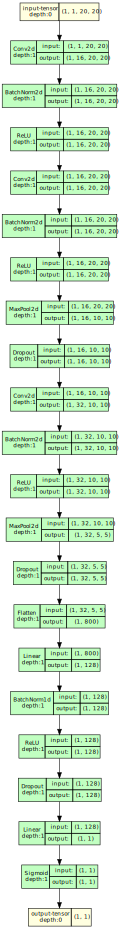

In [13]:
from torchview import draw_graph

# input_size must match your (batch, channels, H, W)
model_graph = draw_graph(model, input_size=(1, 1, 20, 20), expand_nested=True)
model_graph.visual_graph

In [134]:
data_root_path = 'data'

# Define target datasets to run (can be modified)
target_ids = ['20']

all_data_names = sorted([
    name for name in os.listdir(data_root_path)
    if os.path.isdir(os.path.join(data_root_path, name)) and name.startswith('data')
])

# Filter datasets to only include those in target_ids
data_names = []
for name in all_data_names:
    # Check if name matches data{id} or data{id}_...
    for tid in target_ids:
        if name == f"data{tid}" or name.startswith(f"data{tid}_"):
            data_names.append(name)
            break


result_dict, base_weights = wl_train_and_test(data_names[0], None)
torch.save(base_weights, 'base_weights.pth')



Generating Raw CWT: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 14124/14124 [00:04<00:00, 3414.89it/s]


Using device: cuda


Training:  41%|████████████████████████████████████████████████████████████████████████████████▉                                                                                                                      | 61/150 [01:37<02:22,  1.60s/it]

Early stopping at epoch 61.


epoch,▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇███
lr,██████▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/accuracy,▇▇▇▁▇██▇████████████████████████████████
test/auc,▅▇▇▁▇▇██████████████████████████████████
test/f1,▆▅▇▆▁▆▇▇▇▇████▇██████████████▇█████▇████
train/accuracy,▁▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇███████████████████████
train/loss,█▇▆▅▅▄▄▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_accuracy,0.81422
epoch,61
lr,0.0
test/accuracy,0.814


# Playground END

In [5]:
#Hyper parameters
batch_size = 64
model_type = 'CNN_model'
lr = 1e-3
weight_decay = 1e-4
patience = 40
epochs = 150
step_size = 8
gamma = 0.3
wavelet = 'morl'
norm_type = 'none'
base_weights = None

current_run_name = "small-wavenet-model_v4-hp_v4-NO_TL-1"
current_notes = '''
In the previous run, minmax had terrible results, now using no normalization to understand the impact
'''

In [6]:
import numpy as np
import pywt
import torch
from torch.utils.data import Dataset, DataLoader
from sktime.datasets import load_from_tsfile_to_dataframe
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch.nn.functional as F
import torch.nn as nn
from torch.optim.lr_scheduler import StepLR
import pandas as pd
import sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import json
import os
os.environ["WANDB_API_KEY"] = "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"
import wandb
import copy


In [7]:
def cwt_transform(signal, wavelet='morl', scales=np.arange(1, 21)):
    signal = np.array(signal)
    coefs, _ = pywt.cwt(signal, scales, wavelet)
    return coefs  # shape: [scale, time]

In [8]:
class CWTTimeSeriesDataset(Dataset):
    def __init__(self, x_df, y_list, wavelet, scales, norm_type='std'):
        """
        Args:
            norm_type: 'std' for Mean/Std normalization, 
                       'minmax' for 0-1 scaling, 
                       None for no normalization.
        """
        self.samples = []
        self.labels = []
        raw_images = []

        # Step 1: Generate all raw CWT images first
        for i in tqdm(range(len(x_df)), desc="Generating Raw CWT"):
            ts = x_df.iloc[i].iloc[0]
            img = cwt_transform(ts, wavelet, scales)
            raw_images.append(img)
            self.labels.append(int(y_list[i]))

        # Step 2: Calculate Global Statistics
        all_data = np.array(raw_images)
        
        if norm_type == 'std':
            global_mean = np.mean(all_data)
            global_std = np.std(all_data)
            print(f"Global Mean: {global_mean:.4f}, Global Std: {global_std:.4f}")
            
            for img in raw_images:
                norm_img = (img - global_mean) / (global_std + 1e-8)
                self.samples.append(torch.tensor(norm_img, dtype=torch.float32).unsqueeze(0))

        elif norm_type == 'minmax':
            global_min = np.min(all_data)
            global_max = np.max(all_data)
            print(f"Global Min: {global_min:.4f}, Global Max: {global_max:.4f}")
            
            for img in raw_images:
                norm_img = (img - global_min) / (global_max - global_min + 1e-8)
                self.samples.append(torch.tensor(norm_img, dtype=torch.float32).unsqueeze(0))
        
        else:
            for img in raw_images:
                self.samples.append(torch.tensor(img, dtype=torch.float32).unsqueeze(0))

    def plot(self, idx):
        img = self.samples[idx].squeeze(0).numpy()  # shape: [scale, time]
        plt.imshow(
            img,
            extent=[0, img.shape[1], 1, img.shape[0] + 1],
            cmap='PRGn',
            aspect='auto',
            vmax=abs(img).max(),
            vmin=-abs(img).max()
        )
        plt.title(f"CWT of Sample {idx}")
        plt.ylabel('Scale')
        plt.xlabel('Time')
        plt.colorbar(label='Amplitude')
        plt.show()

    def resize_images(self, new_size=(224, 224)):
        resized_samples = []
        for img in tqdm(self.samples, desc="Resizing images"):
            resized_img = F.interpolate(img.unsqueeze(0), size=new_size, mode='bilinear', align_corners=False)
            resized_samples.append(resized_img.squeeze(0))
        self.samples = resized_samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx], self.labels[idx]


In [9]:
''' #Base model
def CNN_model(): # Only works for input size of (b, 1, 20, 20)
    model = nn.Sequential(
        nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.BatchNorm2d(16), nn.ReLU(),
        nn.Conv2d(16, 16, kernel_size=3, padding=1), nn.BatchNorm2d(16), nn.ReLU(),
        nn.MaxPool2d(2, 2), nn.Dropout(0.2),

        nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
        nn.MaxPool2d(2, 2), nn.Dropout(0.3),

        nn.Flatten(),
        nn.Linear(32 * 5 * 5, 128), nn.BatchNorm1d(128), nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(128, 1),
        nn.Sigmoid()
    )
    return model
'''

' #Base model\ndef CNN_model(): # Only works for input size of (b, 1, 20, 20)\n    model = nn.Sequential(\n        nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.BatchNorm2d(16), nn.ReLU(),\n        nn.Conv2d(16, 16, kernel_size=3, padding=1), nn.BatchNorm2d(16), nn.ReLU(),\n        nn.MaxPool2d(2, 2), nn.Dropout(0.2),\n\n        nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),\n        nn.MaxPool2d(2, 2), nn.Dropout(0.3),\n\n        nn.Flatten(),\n        nn.Linear(32 * 5 * 5, 128), nn.BatchNorm1d(128), nn.ReLU(),\n        nn.Dropout(0.4),\n        nn.Linear(128, 1),\n        nn.Sigmoid()\n    )\n    return model\n'

In [10]:
''' Second model with expanded layers
def CNN_model(): 
    # Input size: (batch, 1, 20, 20)
    model = nn.Sequential(
        # Block 1
        nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.BatchNorm2d(16), nn.ReLU(),
        nn.Conv2d(16, 16, kernel_size=3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), # Added depth
        nn.MaxPool2d(2, 2), nn.Dropout(0.2), # Output: (16, 10, 10)

        # Block 2
        nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
        nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), # Added depth
        nn.MaxPool2d(2, 2), nn.Dropout(0.2), # Output: (32, 5, 5)

        # Block 3 (New Deep Block)
        nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
        nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
        nn.Dropout(0.2), # Output: (32, 5, 5)

        nn.Flatten(),
        nn.Linear(32 * 5 * 5, 128), nn.BatchNorm1d(128), nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(128, 1),
        nn.Sigmoid()
    )
    return model
'''

' Second model with expanded layers\ndef CNN_model(): \n    # Input size: (batch, 1, 20, 20)\n    model = nn.Sequential(\n        # Block 1\n        nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.BatchNorm2d(16), nn.ReLU(),\n        nn.Conv2d(16, 16, kernel_size=3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), # Added depth\n        nn.MaxPool2d(2, 2), nn.Dropout(0.2), # Output: (16, 10, 10)\n\n        # Block 2\n        nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),\n        nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), # Added depth\n        nn.MaxPool2d(2, 2), nn.Dropout(0.2), # Output: (32, 5, 5)\n\n        # Block 3 (New Deep Block)\n        nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),\n        nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),\n        nn.Dropout(0.2), # Output: (32, 5, 5)\n\n        nn.Flatten(),\n        nn.Linear(32 * 5 * 5, 128), nn.BatchNorm1d(128)

In [11]:
 #Model v3
def CNN_model(): #Model with deeper and wider network
    # Input size: (batch, 1, 20, 20)
    model = nn.Sequential(
        # Block 1: 16 -> 32 Filters
        nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
        nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
        nn.MaxPool2d(2, 2), nn.Dropout(0.2), # Output: (32, 10, 10)

        # Block 2: 32 -> 64 Filters
        nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
        nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
        nn.MaxPool2d(2, 2), nn.Dropout(0.2), # Output: (64, 5, 5)

        # Block 3: 32 -> 128 Filters
        nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
        nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
        nn.Dropout(0.2), # Output: (128, 5, 5)

        nn.Flatten(),
        # Updated input features for Linear layer: 128 filters * 5 * 5
        nn.Linear(128 * 5 * 5, 256), nn.BatchNorm1d(256), nn.ReLU(), # Increased to 256
        nn.Dropout(0.4),
        nn.Linear(256, 1),
        nn.Sigmoid()
    )
    return model


In [12]:
'''
def CNN_model(): # Model v4
    # Input size: (batch, 1, 20, 20)
    model = nn.Sequential(
        # Block 1: 32 -> 64 Filters
        nn.Conv2d(1, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
        nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
        nn.MaxPool2d(2, 2), nn.Dropout(0.2), # Output: (64, 10, 10)

        # Block 2: 64 -> 128 Filters
        nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
        nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
        nn.MaxPool2d(2, 2), nn.Dropout(0.2), # Output: (128, 5, 5)

        # Block 3: 128 -> 256 Filters
        nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
        nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
        nn.Dropout(0.2), # Output: (256, 5, 5)

        # Block 4: 256 -> 512 Filters
        nn.Conv2d(256, 512, kernel_size=3, padding=1), nn.BatchNorm2d(512), nn.ReLU(),
        nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.BatchNorm2d(512), nn.ReLU(),
        nn.Dropout(0.2), # Output: (512, 5, 5)

        nn.Flatten(),
        # 512 filters * 5 * 5 = 12,800 features
        nn.Linear(512 * 5 * 5, 512), nn.BatchNorm1d(512), nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(512, 1),
        nn.Sigmoid()
    )
    return model
'''

'\ndef CNN_model(): # Model v4\n    # Input size: (batch, 1, 20, 20)\n    model = nn.Sequential(\n        # Block 1: 32 -> 64 Filters\n        nn.Conv2d(1, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),\n        nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),\n        nn.MaxPool2d(2, 2), nn.Dropout(0.2), # Output: (64, 10, 10)\n\n        # Block 2: 64 -> 128 Filters\n        nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),\n        nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),\n        nn.MaxPool2d(2, 2), nn.Dropout(0.2), # Output: (128, 5, 5)\n\n        # Block 3: 128 -> 256 Filters\n        nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),\n        nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),\n        nn.Dropout(0.2), # Output: (256, 5, 5)\n\n        # Block 4: 256 -> 512 Filters\n        nn.Conv2d(256, 512, kernel_siz

In [13]:

def model_fit(train_loader, test_loader, device, weights=None, 
              project_name="small-wavelet-project", run_name=None, notes=None):
    
    # 1. Centralized Configuration    
    config = {
            "batch_size": batch_size,
            "model_type": model_type,
            "lr": lr,
            "weight_decay": weight_decay,
            "patience": patience,
            "epochs": epochs,
            "step_size": step_size,
            "gamma": gamma,
            "wavelet": wavelet,
            "norm_type": norm_type, 
            "data_name" : data_name
        }

    # 2. Initialize WandB with Name and Notes
    wandb.init(
        project=project_name, 
        name=run_name,  # Appears in the "Name" column
        notes=notes,    # Appears in the "Notes" column for context
        config=config
    )
    
    model = CNN_model().to(device)
    
    if weights is not None:
        model.load_state_dict(weights)
        print("Model loaded with provided weights.")

    criterion = nn.BCELoss()
    
    # Use config values for Optimizer and Scheduler
    optimizer = torch.optim.Adam(
        model.parameters(), 
        lr=config["lr"], 
        weight_decay=config["weight_decay"]
    )
    
    scheduler = StepLR(
        optimizer, 
        step_size=config["step_size"], 
        gamma=config["gamma"]
    )
    
    # 3. Tracking Variables
    best_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())
    early_stop_counter = 0
    
    for epoch in tqdm(range(config["epochs"]), desc="Training"):
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0
    
        for x, y in train_loader:
            x, y = x.to(device), y.to(device).float().unsqueeze(1)
            
            optimizer.zero_grad()
            probs = model(x)
            loss = criterion(probs, y)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * x.size(0)
            preds = (probs > 0.5).float()
            correct_train += (preds == y).sum().item() 
            total_train += y.size(0)
    
        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step()
        
        epoch_train_loss = running_loss / total_train
        epoch_train_acc = correct_train / total_train

        log_contents = {
            "epoch": epoch,
            "train/loss": epoch_train_loss,
            "train/accuracy": epoch_train_acc,
            "lr": current_lr
        }
        
        if test_loader is not None:
            accuracy, recall, precision, f1, auc = evaluate_metrics(model, test_loader, device)
            
            log_contents.update({
                "test/accuracy": accuracy,
                "test/f1": f1,
                "test/auc": auc
            })

            if accuracy > best_acc:
                best_acc = accuracy
                best_model_wts = copy.deepcopy(model.state_dict())
                wandb.run.summary["best_accuracy"] = best_acc
                early_stop_counter = 0 
            else:
                early_stop_counter += 1

        wandb.log(log_contents)

        if early_stop_counter >= config["patience"]:
            print(f"Early stopping at epoch {epoch}.")
            break

    model.load_state_dict(best_model_wts)
    updated_weights = model.state_dict()
    wandb.finish()
    
    return model, updated_weights
    

In [14]:
def evaluate_metrics(model, dataloader, device, threshold=0.5):
    """
    Model outputs probabilities in [0,1] (already passed through Sigmoid).
    Returns: accuracy, recall, precision, f1, auc
    """
    model.eval()

    y_true_all = []
    y_pred_all = []
    y_proba_all = []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            y = y.to(device).float().view(-1)     # [B]
            
            probs = model(x).view(-1).float()     # [B], already probabilities
            preds = (probs >= threshold).float()  # [B]

            y_true_all.append(y.cpu())
            y_pred_all.append(preds.cpu())
            y_proba_all.append(probs.cpu())

    y_test = torch.cat(y_true_all).numpy()
    y_pred = torch.cat(y_pred_all).numpy()
    y_proba = torch.cat(y_proba_all).numpy()

    # metrics (as requested)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    try:
        auc = roc_auc_score(y_test, y_proba)
    except ValueError:
        auc = float("nan")

    return accuracy, recall, precision, f1, auc

In [15]:
def wl_train_and_test(data_name, base_weights):

    scales = np.arange(1, 21)
    
    # Extract ID for tracking (e.g., from 'data13_...' to '13')
    data_id = data_name[4:6]
    
    file_path_train = f"data/{data_name}/TokenItaly_vers0/TokenItaly_vers0_TRAIN.ts"
    file_path_test = f"data/{data_name}/TokenItaly_vers0/TokenItaly_vers0_TEST.ts"

    x_train, y_train = load_from_tsfile_to_dataframe(file_path_train)
    x_test, y_test = load_from_tsfile_to_dataframe(file_path_test)

    # 1. Dataset and Loader setup
    train_dataset = CWTTimeSeriesDataset(x_train, y_train, wavelet, scales, norm_type=norm_type)
    val_dataset = CWTTimeSeriesDataset(x_test, y_test, wavelet, scales, norm_type=norm_type)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f'Using device: {device}')


    # 2. Call the upgraded model_fit
    # Note: we now pass val_loader as the second argument
    model, weights = model_fit(
        train_loader=train_loader, 
        test_loader=val_loader, 
        device=device, 
        weights=base_weights,
        project_name="small-wavelet-project",
        run_name=current_run_name,
        notes=current_notes
    )

    # 3. Final Evaluation (W&B is finished inside model_fit, so we do one last check)
    accuracy, recall, precision, f1, auc = evaluate_metrics(model, val_loader, device)
    
    result_dict = {
        "data_id": data_id,
        "data_name": data_name,
        "model": "SmallWaveNetTL",
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "ROC-AUC score": auc
    }

    return result_dict, weights

In [16]:
json_path = 'results.json'
csv_path = 'results.csv'

if os.path.exists(json_path):
    with open(json_path, 'r') as f:
        all_results = json.load(f)
else:
    all_results = []

data_root_path = 'data'

# Define target datasets to run (can be modified)
target_ids = ['10', '11', '12', '13']

all_data_names = sorted([
    name for name in os.listdir(data_root_path)
    if os.path.isdir(os.path.join(data_root_path, name)) and name.startswith('data')
])

# Filter datasets to only include those in target_ids
data_names = []
for name in all_data_names:
    # Check if name matches data{id} or data{id}_...
    for tid in target_ids:
        if name == f"data{tid}" or name.startswith(f"data{tid}_"):
            data_names.append(name)
            break


c = 0
for data_name in data_names:
    result_dict, _ = wl_train_and_test(data_name, base_weights)
    all_results.append(result_dict)
    c += 1
    print(data_name)

with open(json_path, 'w') as f:
    json.dump(all_results, f, indent=2)


df = pd.DataFrame(all_results)
df.to_csv(csv_path, index=False)

print(f"{c} data is trained and results added to the files...")

Generating Raw CWT: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4970/4970 [00:01<00:00, 3418.90it/s]
/opt/conda/lib/python3.10/site-packages/torch/cuda/__init__.py:107: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /opt/conda/conda-bld/pytorch_1678411187366/work/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


Using device: cpu


wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


Training:   3%|████▏                                                                                                                                                          | 4/150 [00:16<10:12,  4.20s/it]


KeyboardInterrupt: 